# Niveau 1 - Tâche 3 : K-Nearest Neighbors (KNN)

**Dataset choisi : Iris**

Dataset de référence pour la classification : 150 échantillons, 4 variables numériques, 3 classes bien séparées (`setosa`, `versicolor`, `virginica`).

**Objectifs couverts :**
1. Entraînement d'un modèle KNN
2. Évaluation (accuracy, matrice de confusion, précision/rappel)
3. Comparaison de plusieurs valeurs de K

**Outils :** Python, scikit-learn, pandas


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score

df = pd.read_csv('data/iris.csv')
print(df.shape)
df.head()


(150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


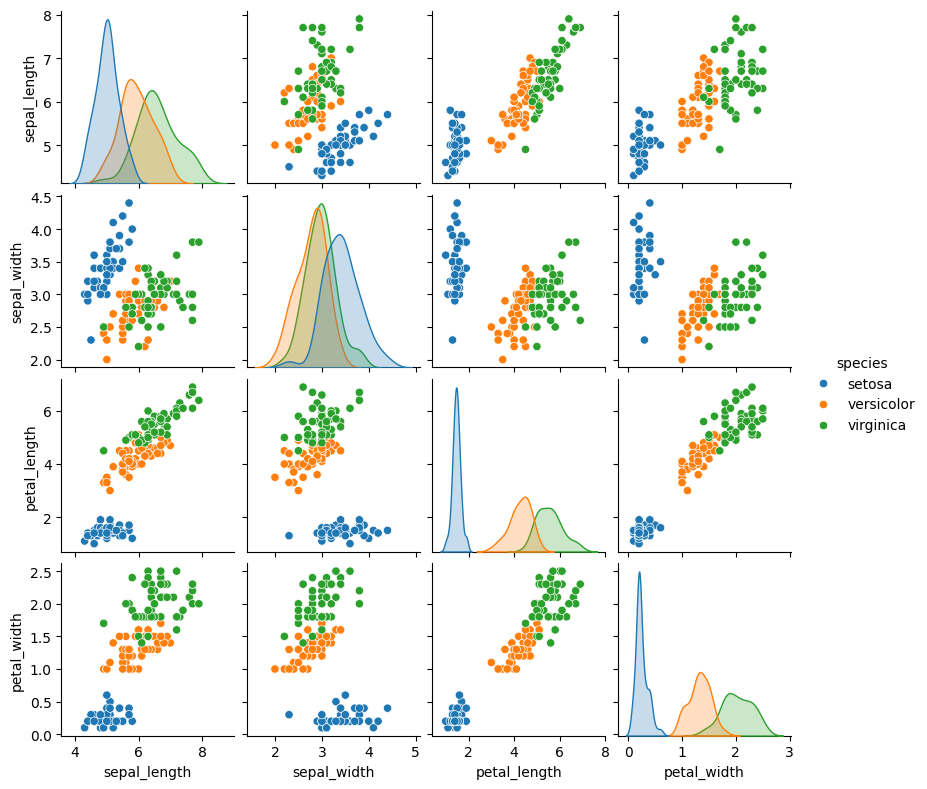

In [2]:
sns.pairplot(df, hue='species', height=2)
plt.show()


## 1. Préparation des données

In [3]:
le = LabelEncoder()
X = df.drop(columns=['species'])
y = le.fit_transform(df['species'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train:", X_train_s.shape, " Test:", X_test_s.shape)
print("Classes:", dict(enumerate(le.classes_)))


Train: (120, 4)  Test: (30, 4)
Classes: {0: 'setosa', 1: 'versicolor', 2: 'virginica'}


## 2. Entraînement du modèle KNN (K=5) et évaluation

In [4]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train)
y_pred = knn.predict(X_test_s)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy (K=5): {acc:.3f}\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Accuracy (K=5): 0.933

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



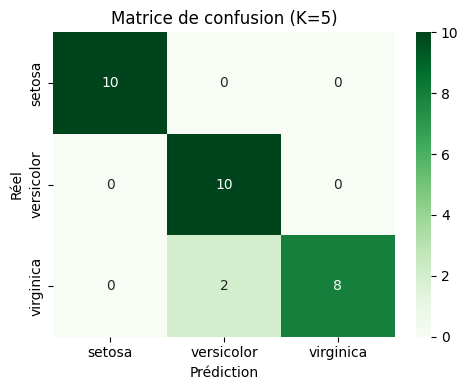

In [5]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Prédiction'); plt.ylabel('Réel')
plt.title('Matrice de confusion (K=5)')
plt.tight_layout()
plt.show()


## 3. Comparaison de différentes valeurs de K

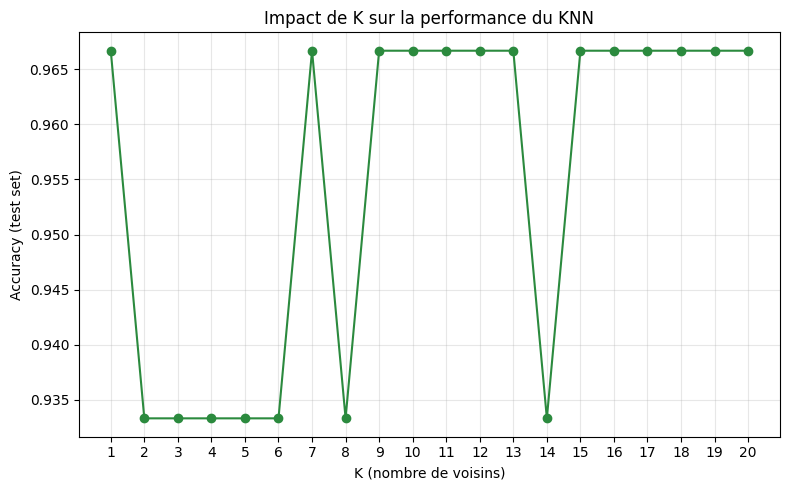

Meilleur K trouvé : 1 (accuracy = 0.967)


In [6]:
k_values = range(1, 21)
accuracies = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)
    accuracies.append(accuracy_score(y_test, pred))

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), accuracies, marker='o', color='#2b8a3e')
plt.xlabel('K (nombre de voisins)')
plt.ylabel('Accuracy (test set)')
plt.title("Impact de K sur la performance du KNN")
plt.xticks(list(k_values))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_k = list(k_values)[int(np.argmax(accuracies))]
print(f"Meilleur K trouvé : {best_k} (accuracy = {max(accuracies):.3f})")


## Conclusion

Le classifieur KNN atteint une très bonne accuracy sur le dataset Iris (dataset simple et bien séparé linéairement/localement).
Le choix de K a un impact modéré ici étant donné la petite taille du dataset et sa faible complexité — de petites valeurs de K (3 à 7) donnent généralement les meilleurs résultats sans sur-apprentissage ni sous-apprentissage.
